In [13]:
# ── Cell 1: Imports ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import optuna
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from xgboost import XGBRegressor
from Preprocess import preprocess_data_window
from catboost import CatBoostRegressor

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [14]:
# ── Cell 2: Load data ────────────────────────────────────────────────────────
data_orig     = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
filtered_time = pd.read_csv("../filtered_time_to_next_event.csv")

In [15]:
# ── Cell 3: Preprocessing ────────────────────────────────────────────────────
n_previous_events = 20
n_qubits_base = 6

X_train, X_val, X_test, y_train, y_val, y_test, feature_cols = preprocess_data_window(
    filtered_time, data_orig, n_previous_events
)

'''rn = np.random.default_rng(seed=42) 

def maybe_subset_split(
    X: np.ndarray,
    y: np.ndarray,
    frac: float,
    rng: np.random.Generator,
) :
    if frac >= 1.0:
        return X, y
    n = len(X)
    if n == 0:
        return X, y
    keep = max(1, int(n * frac))
    idx = rng.choice(n, size=keep, replace=False)
    idx.sort()
    return X[idx], y[idx]
X_train, y_train = maybe_subset_split(X_train, y_train, frac=0.1, rng=rn)
X_val, y_val = maybe_subset_split(X_train, y_train, frac=0.1, rng=rn)
X_test, y_test = maybe_subset_split(X_train, y_train, frac=0.1, rng=rn)'''


print("NaN count per column:\n", X_train.isna().sum())
print("Total NaN:", X_train.isna().sum().sum())

X shape:  (2822, 126)
y shape:  (2822,)
NaN count per column:
 tide_deriv-0      0
form_fac-0        0
time_since-0      0
slip_size-0       0
high_t_evt-0      0
                 ..
form_fac-20       0
time_since-20     0
slip_size-20      0
high_t_evt-20     0
tide_height-20    0
Length: 126, dtype: int64
Total NaN: 0


In [16]:
# ── Cell 4: Config ───────────────────────────────────────────────────────────
QRC_CONFIG = {
    "num_layers_per_event": 2,
    "shots": 4096, #put back at 4096 for true best 
    "n_iterations": 5,
    "top_k": 3,
    "correlation_threshold": 0.0,
    "random_seed": 42,
}

CLASSICAL_MODEL_NAME = "XGBoost"
n_previous_events = 20
SHORT_THRESHOLD = 65_000

print("QRC Config:", QRC_CONFIG)
print("Classical model:", CLASSICAL_MODEL_NAME)
print(f"Regime boundary: {SHORT_THRESHOLD}s")

QRC Config: {'num_layers_per_event': 2, 'shots': 4096, 'n_iterations': 5, 'top_k': 3, 'correlation_threshold': 0.0, 'random_seed': 42}
Classical model: XGBoost
Regime boundary: 65000s


In [17]:
# ── Cell 5+6: Scaling ─────────────────────────────────────────────────────────
def scale_to_pi_range(X_train, X_val, X_test):
    train_min = X_train.min(axis=0)
    train_max = X_train.max(axis=0)
    denom = train_max - train_min
    denom[denom == 0] = 1.0

    def transform(X):
        scaled = (X - train_min) / denom
        scaled = np.clip(scaled, 0.0, 1.0)
        return scaled * np.pi

    return transform(X_train), transform(X_val), transform(X_test)


X_train_sel = X_train.to_numpy()
X_val_sel   = X_val.to_numpy()
X_test_sel  = X_test.to_numpy()

X_train_q, X_val_q, X_test_q = scale_to_pi_range(X_train_sel, X_val_sel, X_test_sel)

# Convert targets to numpy once here for use throughout
y_train_np = y_train.to_numpy() if hasattr(y_train, "to_numpy") else np.array(y_train)
y_val_np   = y_val.to_numpy()   if hasattr(y_val,   "to_numpy") else np.array(y_val)
y_test_np  = y_test.to_numpy()  if hasattr(y_test,  "to_numpy") else np.array(y_test)

n_qubits       = n_qubits_base
n_states       = 2 ** n_qubits
n_total_events = n_previous_events + 1

print(f"Input to quantum circuit: {X_train_q.shape}")
print(f"n_qubits: {n_qubits}, n_states: {n_states}")
print(f"Total events per sample: {n_total_events}")

Input to quantum circuit: (1692, 126)
n_qubits: 6, n_states: 64
Total events per sample: 21


In [19]:
# ── Cell 6: Unsupervised regime labelling (K-Means on y) + classifier ────────
#
# Step 1: K-Means on y_train_np → unsupervised regime labels 
# Step 2: XGBoost trained on X_train_q to predict those labels from features
# Step 3: Val/test routed via XGBoost only — no future y used at inference
#
import numpy as np
import optuna
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, classification_report,
                             silhouette_score)
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Step 1: K-Means on y_train_np ────────────────────────────────────────────
km_y = KMeans(n_clusters=2, n_init=50, random_state=42)
km_y.fit(y_train_np.reshape(-1, 1))

# Sort so cluster 0 = short, cluster 1 = long
order  = np.argsort(km_y.cluster_centers_.ravel())
remap  = {old: new for new, old in enumerate(order)}
centers = km_y.cluster_centers_.ravel()[order]

def _km_label(y_arr):
    """Assign regime labels via trained K-Means (uses y — training only)."""
    raw = km_y.predict(y_arr.reshape(-1, 1))
    return np.array([remap[r] for r in raw])

# Ground-truth regime labels derived from y (used for training + evaluation)
y_clf_train = _km_label(y_train_np)
y_clf_val   = _km_label(y_val_np)
y_clf_test  = _km_label(y_test_np)

boundary = centers.mean()
print(f"K-Means cluster centres — Short: {centers[0]:.0f} s, Long: {centers[1]:.0f} s")
print(f"Decision boundary (midpoint): {boundary:.0f} s")

sil_train = silhouette_score(y_train_np.reshape(-1, 1), y_clf_train)
sil_val   = silhouette_score(y_val_np.reshape(-1, 1),   y_clf_val)
sil_test  = silhouette_score(y_test_np.reshape(-1, 1),  y_clf_test)
print(f"Silhouette score — Train: {sil_train:.4f}, Val: {sil_val:.4f}, Test: {sil_test:.4f}")

print(f"\nClass distribution (train) — Short: {(y_clf_train==0).sum()}, Long: {(y_clf_train==1).sum()}")
print(f"Class distribution (val)   — Short: {(y_clf_val==0).sum()},   Long: {(y_clf_val==1).sum()}")
print(f"Class distribution (test)  — Short: {(y_clf_test==0).sum()},  Long: {(y_clf_test==1).sum()}")

# ── Step 2: Train XGBoost classifier on X to predict K-Means labels ──────────
# From this point on, y is never used — only X and the K-Means-derived labels
sample_weights_clf = compute_sample_weight("balanced", y_clf_train)

def clf_objective(trial):
    clf = XGBClassifier(
        objective="binary:logistic",
        n_estimators=500,
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        max_depth=trial.suggest_int("max_depth", 2, 6),
        subsample=trial.suggest_float("subsample", 0.6, 0.9),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 0.9),
        scale_pos_weight=trial.suggest_float("scale_pos_weight", 0.5, 3.0),
        random_state=42,
        eval_metric="logloss",
    )
    clf.fit(
        X_train_q, y_clf_train,
        sample_weight=sample_weights_clf,
        eval_set=[(X_val_q, y_clf_val)],
        verbose=False,
    )
    preds = clf.predict(X_val_q)
    return 1.0 - accuracy_score(y_clf_val, preds)

clf_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
clf_study.optimize(clf_objective, n_trials=30)

slip_classifier = XGBClassifier(
    objective="binary:logistic",
    n_estimators=500,
    **clf_study.best_params,
    random_state=42,
    eval_metric="logloss",
)
slip_classifier.fit(
    X_train_q, y_clf_train,
    sample_weight=sample_weights_clf,
    eval_set=[(X_val_q, y_clf_val)],
    verbose=False,
)

# ── Step 3: Evaluate classifier (X → predicted regime, no y used) ─────────────
clf_train_acc = accuracy_score(y_clf_train, slip_classifier.predict(X_train_q))
clf_val_acc   = accuracy_score(y_clf_val,   slip_classifier.predict(X_val_q))
clf_test_acc  = accuracy_score(y_clf_test,  slip_classifier.predict(X_test_q))

print(f"\nClassifier accuracy — Train: {clf_train_acc:.4f}, Val: {clf_val_acc:.4f}, Test: {clf_test_acc:.4f}")
print(f"\nClassification report (test):")
print(classification_report(y_clf_test, slip_classifier.predict(X_test_q),
                             target_names=["Short", "Long"]))

# ── Regime masks (train) using K-Means labels ─────────────────────────────────
short_mask_train = y_clf_train == 0
long_mask_train  = y_clf_train == 1
short_mask_val   = y_clf_val   == 0
long_mask_val    = y_clf_val   == 1

# ── Routing indices using classifier predictions (X only — inference-safe) ────
clf_test_labels = slip_classifier.predict(X_test_q)
clf_val_labels  = slip_classifier.predict(X_val_q)
short_test_idx  = np.where(clf_test_labels == 0)[0]
long_test_idx   = np.where(clf_test_labels == 1)[0]
short_val_idx   = np.where(clf_val_labels  == 0)[0]
long_val_idx    = np.where(clf_val_labels  == 1)[0]

print(f"\nTest routing  — Short: {len(short_test_idx)}, Long: {len(long_test_idx)}")
print(f"Val routing   — Short: {len(short_val_idx)},  Long: {len(long_val_idx)}")

if clf_val_acc < 0.75:
    print(f"\nWARNING: Classifier val accuracy {clf_val_acc:.4f} is below 0.75.")
else:
    print(f"\nClassifier val accuracy {clf_val_acc:.4f} — proceeding.")

K-Means cluster centres — Short: 45889 s, Long: 83860 s
Decision boundary (midpoint): 64875 s
Silhouette score — Train: 0.7208, Val: 0.7099, Test: 0.7230

Class distribution (train) — Short: 1054, Long: 638
Class distribution (val)   — Short: 357,   Long: 208
Class distribution (test)  — Short: 367,  Long: 198

Classifier accuracy — Train: 1.0000, Val: 0.7982, Test: 0.8389

Classification report (test):
              precision    recall  f1-score   support

       Short       0.88      0.88      0.88       367
        Long       0.77      0.77      0.77       198

    accuracy                           0.84       565
   macro avg       0.82      0.82      0.82       565
weighted avg       0.84      0.84      0.84       565


Test routing  — Short: 368, Long: 197
Val routing   — Short: 379,  Long: 186

Classifier val accuracy 0.7982 — proceeding.


In [20]:
# ── Cell 7: FC-TFI Hamiltonian ────────────────────────────────────────────────
def generate_ising_params(n_qubits, rng, J_std=0.5, h=1.0, t=0.5):
    J = np.zeros((n_qubits, n_qubits))
    for i in range(n_qubits):
        for j in range(i + 1, n_qubits):
            J[i, j] = rng.normal(0, J_std)
    return J, h, t


def trotter_ising_layer(qc, n_qubits, J, h, t, n_trotter_steps=3):
    dt = t / n_trotter_steps
    for _ in range(n_trotter_steps):
        for i in range(n_qubits):
            for j in range(i + 1, n_qubits):
                if abs(J[i, j]) > 1e-10:
                    qc.cx(i, j)
                    qc.rz(2 * J[i, j] * dt, j)
                    qc.cx(i, j)
        for i in range(n_qubits):
            qc.rx(2 * h * dt, i)


def encode_rotations(qc, data_sample, n_qubits):
    for i in range(n_qubits):
        qc.ry(float(data_sample[i]), i)


def build_reservoir_circuit_rotations(data_sample, ising_params, num_layers, n_qubits):
    J, h, t = ising_params
    qc = QuantumCircuit(n_qubits)

    for i in range(n_qubits):
        qc.h(i)

    encode_rotations(qc, data_sample, n_qubits)
    qc.barrier()

    for layer in range(num_layers):
        trotter_ising_layer(qc, n_qubits, J, h, t)
        qc.barrier()

        encode_rotations(qc, data_sample, n_qubits)
        qc.barrier()

        trotter_ising_layer(qc, n_qubits, J, h, t)
        qc.barrier()

    return qc


def generate_random_angles(num_layers, n_qubits, rng):
    return generate_ising_params(n_qubits, rng)

In [21]:
# ── Cell 8: Pauli runner — quantum features only, no classical concatenation ───
def get_pauli_expectations(circuit_base, n_qubits, shots, simulator):
    expectations = np.zeros(3 * n_qubits)

    for basis_idx, basis in enumerate(['Z', 'X', 'Y']):
        qc_meas = circuit_base.copy()

        if basis == 'X':
            for i in range(n_qubits):
                qc_meas.h(i)
        elif basis == 'Y':
            for i in range(n_qubits):
                qc_meas.sdg(i)
                qc_meas.h(i)

        qc_meas.measure_all()
        result = simulator.run(qc_meas, shots=shots).result()
        counts = result.get_counts()

        for bitstring, count in counts.items():
            bits = bitstring.replace(" ", "")
            for qubit_idx in range(n_qubits):
                bit = int(bits[n_qubits - 1 - qubit_idx])
                expectations[basis_idx * n_qubits + qubit_idx] += (
                    (1 - 2 * bit) * count / shots
                )

    zz_correlators = np.zeros(n_qubits)
    qc_zz = circuit_base.copy()
    qc_zz.measure_all()
    result_zz = simulator.run(qc_zz, shots=shots).result()
    counts_zz = result_zz.get_counts()

    for bitstring, count in counts_zz.items():
        bits = bitstring.replace(" ", "")
        for i in range(n_qubits):
            j = (i + 1) % n_qubits
            bit_i = int(bits[n_qubits - 1 - i])
            bit_j = int(bits[n_qubits - 1 - j])
            zz_correlators[i] += (
                (1 - 2*bit_i) * (1 - 2*bit_j) * count / shots
            )

    return np.concatenate([expectations, zz_correlators])


def run_quantum_reservoir_pauli(
    X_data, angle_bank, num_layers, n_qubits, n_total_events, shots
):
    if hasattr(X_data, 'values'):
        X_data = X_data.to_numpy()

    m         = X_data.shape[0]
    n_obs     = 3 * n_qubits + n_qubits  # 24
    simulator = AerSimulator()
    pauli_matrix = np.zeros((m, n_total_events * n_obs))

    for event_idx in range(n_total_events):
        start_col    = event_idx * n_qubits
        end_col      = start_col + n_qubits
        X_event      = X_data[:, start_col:end_col]
        ising_params = angle_bank[event_idx]

        for sample_idx in range(m):
            qc = build_reservoir_circuit_rotations(
                X_event[sample_idx], ising_params, num_layers, n_qubits
            )
            obs_vals = get_pauli_expectations(qc, n_qubits, shots, simulator)
            pauli_matrix[
                sample_idx,
                event_idx * n_obs:(event_idx + 1) * n_obs
            ] = obs_vals

        print(f"  Event {event_idx + 1}/{n_total_events} done", end="\r")

    print()
    return pauli_matrix


def make_hybrid_features_decay(P_matrix, X_classical, n_total_events, n_obs, decay=0.3):
    weights = np.array([
        np.exp(-decay * (n_total_events - 1 - i))
        for i in range(n_total_events)
    ])
    weights /= weights.sum()

    weighted_P = P_matrix.copy()
    for event_idx in range(n_total_events):
        start = event_idx * n_obs
        end   = start + n_obs
        weighted_P[:, start:end] *= weights[event_idx]
    return weighted_P

In [22]:
# ── Cell 9: Model registry ────────────────────────────────────────────────────
def get_model_registry():
    return {
        "Ridge": {
            "optuna_fn": lambda trial: {
                "alpha": trial.suggest_float("alpha", 1e-2, 1e8, log=True),
            },
            "fixed_params": {},
            "build_fn": lambda params: Ridge(**params),
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(Xt, yt),
            "shap_explainer": "linear",
        },
        "XGBoost": {
            "optuna_fn": lambda trial: {
                "learning_rate":    trial.suggest_float("learning_rate", 0.005, 0.15, log=True),
                "max_depth":        trial.suggest_int("max_depth", 2, 8),
                "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
                "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
                "reg_alpha":        trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
                "reg_lambda":       trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            },
            "fixed_params": {
                "objective":             "reg:squarederror",
                "n_estimators":          2000,
                "random_state":          42,
                "early_stopping_rounds": 75,
                "tree_method":           "hist",
            },
            "build_fn": lambda params: XGBRegressor(**params),
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(
                Xt, yt, eval_set=[(Xv, yv)], verbose=False
            ),
            "shap_explainer": "tree",
        },
        "CatBoost": {
            "optuna_fn": lambda trial: {
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
                "depth":         trial.suggest_int("depth", 2, 8),
            },
            "fixed_params": {
                "iterations":          100,
                "loss_function":       "RMSE",
                "eval_metric":         "RMSE",
                "random_seed":         42,
                "verbose":             False,
                "allow_writing_files": False,
            },
            "build_fn": lambda params: CatBoostRegressor(**params),
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(
                Xt, yt, eval_set=(Xv, yv), use_best_model=True
            ),
            "shap_explainer": "tree",
        },
        "RandomForest": {
            "optuna_fn": lambda trial: {
                "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
                "max_depth":    trial.suggest_int("max_depth", 2, 10),
            },
            "fixed_params": {"random_state": 42},
            "build_fn": lambda params: RandomForestRegressor(**params),
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(Xt, yt),
            "shap_explainer": "tree",
        },
    }


registry = get_model_registry()
print(f"Available models: {list(registry.keys())}")
print(f"Using: {CLASSICAL_MODEL_NAME}")

Available models: ['Ridge', 'XGBoost', 'CatBoost', 'RandomForest']
Using: XGBoost


In [23]:
# ── Cell 10: Single iteration — pre-classified regime-specific reservoirs ──────
def run_single_qrc_iteration(
    iteration_idx,
    X_train_q, X_val_q, X_test_q,
    y_train, y_val, y_test,
    n_qubits, config, model_name, registry,
):
    num_layers     = config["num_layers_per_event"]
    shots          = config["shots"]
    seed           = config["random_seed"] + iteration_idx
    n_total_events = n_previous_events + 1
    n_obs          = 3 * n_qubits + n_qubits  # 24

    rng_short = np.random.default_rng(seed)
    rng_long  = np.random.default_rng(seed + 10000)

    angle_bank_short = [
        generate_random_angles(num_layers, n_qubits, rng_short)
        for _ in range(n_total_events)
    ]
    angle_bank_long = [
        generate_random_angles(num_layers, n_qubits, rng_long)
        for _ in range(n_total_events)
    ]

    # ── Step 1: Split train/val by TRUE regime label ──────────────────────────
    X_tr_short = X_train_q[short_mask_train]
    X_tr_long  = X_train_q[long_mask_train]
    X_vl_short = X_val_q[short_mask_val]
    X_vl_long  = X_val_q[long_mask_val]

    y_tr_short = y_train_np[short_mask_train]
    y_tr_long  = y_train_np[long_mask_train]
    y_vl_short = y_val_np[short_mask_val]
    y_vl_long  = y_val_np[long_mask_val]

    print(f"  Short regime — train: {len(y_tr_short)}, val: {len(y_vl_short)}")
    print(f"  Long  regime — train: {len(y_tr_long)},  val: {len(y_vl_long)}")

    # ── Step 2: Run SHORT regime reservoir ────────────────────────────────────
    print(f"  Running SHORT FC-TFI reservoir on train ({len(X_tr_short)} samples)...")
    P_tr_short = run_quantum_reservoir_pauli(
        X_tr_short, angle_bank_short, num_layers, n_qubits, n_total_events, shots
    )
    print(f"  Running SHORT FC-TFI reservoir on val ({len(X_vl_short)} samples)...")
    P_vl_short = run_quantum_reservoir_pauli(
        X_vl_short, angle_bank_short, num_layers, n_qubits, n_total_events, shots
    )
    print(f"  Running SHORT FC-TFI reservoir on test ({len(short_test_idx)} samples)...")
    P_te_short = run_quantum_reservoir_pauli(
        X_test_q[short_test_idx], angle_bank_short, num_layers, n_qubits, n_total_events, shots
    )

    # ── Step 3: Run LONG regime reservoir ─────────────────────────────────────
    print(f"  Running LONG FC-TFI reservoir on train ({len(X_tr_long)} samples)...")
    P_tr_long = run_quantum_reservoir_pauli(
        X_tr_long, angle_bank_long, num_layers, n_qubits, n_total_events, shots
    )
    print(f"  Running LONG FC-TFI reservoir on val ({len(y_vl_long)} samples)...")
    P_vl_long = run_quantum_reservoir_pauli(
        X_vl_long, angle_bank_long, num_layers, n_qubits, n_total_events, shots
    )
    print(f"  Running LONG FC-TFI reservoir on test ({len(long_test_idx)} samples)...")
    P_te_long = run_quantum_reservoir_pauli(
        X_test_q[long_test_idx], angle_bank_long, num_layers, n_qubits, n_total_events, shots
    )

    # ── Step 4: Quantum-only features with decay ──────────────────────────────
    H_tr_short = make_hybrid_features_decay(P_tr_short, X_tr_short, n_total_events, n_obs)
    H_vl_short = make_hybrid_features_decay(P_vl_short, X_vl_short, n_total_events, n_obs)
    H_te_short = make_hybrid_features_decay(P_te_short, X_test_q[short_test_idx], n_total_events, n_obs)

    H_tr_long  = make_hybrid_features_decay(P_tr_long,  X_tr_long,  n_total_events, n_obs)
    H_vl_long  = make_hybrid_features_decay(P_vl_long,  X_vl_long,  n_total_events, n_obs)
    H_te_long  = make_hybrid_features_decay(P_te_long,  X_test_q[long_test_idx], n_total_events, n_obs)

    entry = registry[model_name]

    # ── Step 5: Tune and train SHORT sub-regressor ────────────────────────────
    def short_objective(trial):
        tuned  = entry["optuna_fn"](trial)
        params = {**entry["fixed_params"], **tuned}
        model  = entry["build_fn"](params)
        entry["fit_fn"](model, H_tr_short, y_tr_short, H_vl_short, y_vl_short)
        return mean_absolute_error(y_vl_short, model.predict(H_vl_short))

    short_study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=seed),
    )
    short_study.optimize(short_objective, n_trials=30)

    short_tuned  = entry["optuna_fn"](short_study.best_trial)
    short_params = {**entry["fixed_params"], **short_tuned}
    model_short  = entry["build_fn"](short_params)
    entry["fit_fn"](model_short, H_tr_short, y_tr_short, H_vl_short, y_vl_short)

    # ── Step 6: Tune and train LONG sub-regressor ─────────────────────────────
    def long_objective(trial):
        tuned  = entry["optuna_fn"](trial)
        params = {**entry["fixed_params"], **tuned}
        model  = entry["build_fn"](params)
        entry["fit_fn"](model, H_tr_long, y_tr_long, H_vl_long, y_vl_long)
        return mean_absolute_error(y_vl_long, model.predict(H_vl_long))

    long_study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=seed + 1),
    )
    long_study.optimize(long_objective, n_trials=30)

    long_tuned  = entry["optuna_fn"](long_study.best_trial)
    long_params = {**entry["fixed_params"], **long_tuned}
    model_long  = entry["build_fn"](long_params)
    entry["fit_fn"](model_long, H_tr_long, y_tr_long, H_vl_long, y_vl_long)

    short_val_mae = mean_absolute_error(y_vl_short, model_short.predict(H_vl_short))
    long_val_mae  = mean_absolute_error(y_vl_long,  model_long.predict(H_vl_long))
    print(f"  Short regime val MAE: {short_val_mae:.2f}s")
    print(f"  Long  regime val MAE: {long_val_mae:.2f}s")

    # ── Step 7: Test predictions routed by classifier ─────────────────────────
    test_pred = np.empty(len(X_test_q))
    if len(short_test_idx) > 0:
        test_pred[short_test_idx] = model_short.predict(H_te_short)
    if len(long_test_idx) > 0:
        test_pred[long_test_idx]  = model_long.predict(H_te_long)

    # ── Step 8: Val predictions using already-computed reservoir outputs ───────
    val_pred = np.empty(len(X_val_q))

    short_val_positions = {
        idx: pos for pos, idx in enumerate(np.where(short_mask_val)[0])
    }
    long_val_positions = {
        idx: pos for pos, idx in enumerate(np.where(long_mask_val)[0])
    }

    for idx in short_val_idx:
        if idx in short_val_positions:
            pos = short_val_positions[idx]
            val_pred[idx] = model_short.predict(H_vl_short[pos:pos+1])[0]
        elif idx in long_val_positions:
            pos = long_val_positions[idx]
            val_pred[idx] = model_short.predict(H_vl_long[pos:pos+1])[0]

    for idx in long_val_idx:
        if idx in long_val_positions:
            pos = long_val_positions[idx]
            val_pred[idx] = model_long.predict(H_vl_long[pos:pos+1])[0]
        elif idx in short_val_positions:
            pos = short_val_positions[idx]
            val_pred[idx] = model_long.predict(H_vl_short[pos:pos+1])[0]

    # ── Step 9: Metrics ───────────────────────────────────────────────────────
    return {
        "iteration":   iteration_idx,
        "val_r2":      r2_score(y_val_np, val_pred),
        "val_rmse":    root_mean_squared_error(y_val_np, val_pred),
        "val_mae":     mean_absolute_error(y_val_np, val_pred),
        "test_rmse":   root_mean_squared_error(y_test_np, test_pred),
        "test_mae":    mean_absolute_error(y_test_np, test_pred),
        "test_pred":   test_pred,
        "best_params": {"short": short_params, "long": long_params},
        "model":       model_short,
        "P_train": P_tr_short, "P_val": P_vl_short, "P_test": P_te_short,
    }

In [24]:
# ── Cell 11: Pipeline + run ───────────────────────────────────────────────────
def run_qrc_pipeline(
    X_train_q, X_val_q, X_test_q,
    y_train, y_val, y_test,
    n_qubits, config, model_name, registry,
):
    results = []
    for i in range(config["n_iterations"]):
        print(f"\nIteration {i + 1}/{config['n_iterations']}:")
        res = run_single_qrc_iteration(
            i,
            X_train_q, X_val_q, X_test_q,
            y_train, y_val, y_test,
            n_qubits, config, model_name, registry,
        )
        print(
            f"\tVal R2: {res['val_r2']:.4f} | Val RMSE: {res['val_rmse']:.2f} | "
            f"Val MAE: {res['val_mae']:.2f} | Test RMSE: {res['test_rmse']:.2f} | "
            f"Test MAE: {res['test_mae']:.2f}"
        )
        results.append(res)

    top_k          = config["top_k"]
    sorted_results = sorted(results, key=lambda r: r["val_mae"])
    top_results    = sorted_results[:top_k]
    top_indices    = [r["iteration"] for r in top_results]

    print(f"\nTop-{top_k} iterations (by val MAE): {[i + 1 for i in top_indices]}")

    ensemble_pred = np.mean([r["test_pred"] for r in top_results], axis=0)
    ensemble_rmse = root_mean_squared_error(y_test_np, ensemble_pred)
    ensemble_mae  = mean_absolute_error(y_test_np, ensemble_pred)
    ensemble_r2   = r2_score(y_test_np, ensemble_pred)

    print(f"\nEnsemble Test RMSE: {ensemble_rmse:.2f}")
    print(f"Ensemble Test MAE:  {ensemble_mae:.2f}")
    print(f"Ensemble Test R2:   {ensemble_r2:.4f}")

    # ── Per-regime test breakdown — comparable to classical Cell A ────────────
    # True-label split (perfect routing) — matches quantum per-iteration printout
    short_true_test = np.where(y_test_np < SHORT_THRESHOLD)[0]
    long_true_test  = np.where(y_test_np >= SHORT_THRESHOLD)[0]

    ensemble_short_mae = mean_absolute_error(
        y_test_np[short_true_test], ensemble_pred[short_true_test]
    )
    ensemble_long_mae = mean_absolute_error(
        y_test_np[long_true_test], ensemble_pred[long_true_test]
    )

    print(f"\n=== Ensemble Per-Regime Test MAE (true-label split) ===")
    print(f"Short regime (true <{SHORT_THRESHOLD:,}s, n={len(short_true_test)}): "
          f"MAE = {ensemble_short_mae:.2f}s")
    print(f"Long  regime (true >={SHORT_THRESHOLD:,}s, n={len(long_true_test)}):  "
          f"MAE = {ensemble_long_mae:.2f}s")

    # Classifier-routed breakdown — shows misrouting cost
    clf_test_preds   = slip_classifier.predict(X_test_q)
    true_test_labels = (y_test_np >= SHORT_THRESHOLD).astype(int)

    short_routed = np.where(clf_test_preds == 0)[0]
    long_routed  = np.where(clf_test_preds == 1)[0]

    correct_short   = short_routed[true_test_labels[short_routed] == 0]
    misrouted_short = short_routed[true_test_labels[short_routed] == 1]
    correct_long    = long_routed[true_test_labels[long_routed] == 1]
    misrouted_long  = long_routed[true_test_labels[long_routed] == 0]

    routing_acc  = np.mean(clf_test_preds == true_test_labels)
    n_misrouted  = np.sum(clf_test_preds != true_test_labels)

    print(f"\n=== Classifier Routing (test set) ===")
    print(f"Routing accuracy: {routing_acc:.4f} "
          f"({n_misrouted} misrouted / {len(y_test_np)} total)")

    if len(correct_short) > 0:
        print(f"Correctly routed short (n={len(correct_short)}): "
              f"MAE = {mean_absolute_error(y_test_np[correct_short], ensemble_pred[correct_short]):.2f}s")
    if len(misrouted_short) > 0:
        print(f"Misrouted to short    (n={len(misrouted_short)}): "
              f"MAE = {mean_absolute_error(y_test_np[misrouted_short], ensemble_pred[misrouted_short]):.2f}s")
    if len(correct_long) > 0:
        print(f"Correctly routed long (n={len(correct_long)}): "
              f"MAE = {mean_absolute_error(y_test_np[correct_long], ensemble_pred[correct_long]):.2f}s")
    if len(misrouted_long) > 0:
        print(f"Misrouted to long     (n={len(misrouted_long)}): "
              f"MAE = {mean_absolute_error(y_test_np[misrouted_long], ensemble_pred[misrouted_long]):.2f}s")

    return results, ensemble_pred, top_indices


all_results, ensemble_pred, top_indices = run_qrc_pipeline(
    X_train_q, X_val_q, X_test_q,
    y_train, y_val, y_test,
    n_qubits, QRC_CONFIG,
    "XGBoost",
    registry,
)


Iteration 1/5:
  Short regime — train: 1054, val: 357
  Long  regime — train: 638,  val: 208
  Running SHORT FC-TFI reservoir on train (1054 samples)...
  Event 21/21 done
  Running SHORT FC-TFI reservoir on val (357 samples)...
  Event 21/21 done
  Running SHORT FC-TFI reservoir on test (368 samples)...
  Event 21/21 done
  Running LONG FC-TFI reservoir on train (638 samples)...
  Event 21/21 done
  Running LONG FC-TFI reservoir on val (208 samples)...
  Event 21/21 done
  Running LONG FC-TFI reservoir on test (197 samples)...
  Event 21/21 done
  Short regime val MAE: 3821.27s
  Long  regime val MAE: 4116.90s
	Val R2: 0.1622 | Val RMSE: 18364.68 | Val MAE: 10565.20 | Test RMSE: 17035.66 | Test MAE: 9095.21

Iteration 2/5:
  Short regime — train: 1054, val: 357
  Long  regime — train: 638,  val: 208
  Running SHORT FC-TFI reservoir on train (1054 samples)...
  Event 21/21 done
  Running SHORT FC-TFI reservoir on val (357 samples)...
  Event 21/21 done
  Running SHORT FC-TFI reservoir

In [33]:


import numpy as np
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error



# ------------------------------------------------------------------
# 1. Convert to numpy and split by TRUE label for sub-model training
# ------------------------------------------------------------------

y_train_np = y_train.to_numpy() if hasattr(y_train, "to_numpy") else np.array(y_train)
y_val_np   = y_val.to_numpy()   if hasattr(y_val,   "to_numpy") else np.array(y_val)
y_test_np  = y_test.to_numpy()  if hasattr(y_test,  "to_numpy") else np.array(y_test)

X_train_np = X_train_q
X_val_np   = X_val_q
X_test_np  = X_test_q

short_mask_train = y_clf_train == 0
long_mask_train  = y_clf_train == 1
short_mask_val   = y_clf_val == 0
long_mask_val    = y_clf_val == 1

X_tr_short, y_tr_short = X_train_np[short_mask_train], y_train_np[short_mask_train]
X_vl_short, y_vl_short = X_val_np[short_mask_val],     y_val_np[short_mask_val]
X_tr_long,  y_tr_long  = X_train_np[long_mask_train],  y_train_np[long_mask_train]
X_vl_long,  y_vl_long  = X_val_np[long_mask_val],      y_val_np[long_mask_val]

print(f"Sub-regressor training samples — Short: {len(y_tr_short)}, Long: {len(y_tr_long)}")

# ------------------------------------------------------------------
# 2. Optuna tuning — SHORT sub-regressor


def objective_short(trial):
    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=1000,
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        max_depth=trial.suggest_int("max_depth", 2, 5),
        subsample=trial.suggest_float("subsample", 0.6, 0.9),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 0.9),
        random_state=42,
    )
    model.fit(X_tr_short, y_tr_short,
              eval_set=[(X_vl_short, y_vl_short)], verbose=False)
    preds = np.clip(model.predict(X_vl_short), SHORT_LOWER, SHORT_UPPER)
    return root_mean_squared_error(y_vl_short, preds)

opt_short = optuna.create_study(direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=42))
opt_short.optimize(objective_short, n_trials=30)
print("Short sub-regressor optimal params:", opt_short.best_params)

# ------------------------------------------------------------------
# 3. Optuna tuning — LONG sub-regressor
# ------------------------------------------------------------------

def objective_long(trial):
    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=1000,
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        max_depth=trial.suggest_int("max_depth", 2, 5),
        subsample=trial.suggest_float("subsample", 0.6, 0.9),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 0.9),
        random_state=42,
    )
    model.fit(X_tr_long, y_tr_long,
              eval_set=[(X_vl_long, y_vl_long)], verbose=False)
    preds = np.clip(model.predict(X_vl_long), LONG_LOWER, LONG_UPPER)
    return root_mean_squared_error(y_vl_long, preds)

opt_long = optuna.create_study(direction="minimize",
                               sampler=optuna.samplers.TPESampler(seed=42))
opt_long.optimize(objective_long, n_trials=30)
print("Long sub-regressor optimal params:", opt_long.best_params)

# ------------------------------------------------------------------
# 4. Train final sub-regressors
# ------------------------------------------------------------------

XGBoost_short = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    **opt_short.best_params,
    random_state=42,
)
XGBoost_short.fit(X_tr_short, y_tr_short,
                  eval_set=[(X_vl_short, y_vl_short)], verbose=False)

XGBoost_long = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    **opt_long.best_params,
    random_state=42,
)
XGBoost_long.fit(X_tr_long, y_tr_long,
                 eval_set=[(X_vl_long, y_vl_long)], verbose=False)

# ------------------------------------------------------------------
# 5. Inference — classifier routes

clf_test_labels = slip_classifier.predict(X_test_np)

final_predictions = np.empty(len(X_test_np))
short_idx = np.where(clf_test_labels == 0)[0]
long_idx  = np.where(clf_test_labels == 1)[0]

if len(short_idx) > 0:
    final_predictions[short_idx] = XGBoost_short.predict(X_test_np[short_idx])

if len(long_idx) > 0:
    final_predictions[long_idx] = XGBoost_long.predict(X_test_np[long_idx])



# Soft range warnings (monitor without distorting metrics)
n_below_short = np.sum(final_predictions[short_idx] < SHORT_LOWER) if len(short_idx) > 0 else 0
n_above_short = np.sum(final_predictions[short_idx] > SHORT_UPPER) if len(short_idx) > 0 else 0
n_below_long  = np.sum(final_predictions[long_idx]  < LONG_LOWER)  if len(long_idx)  > 0 else 0
n_above_long  = np.sum(final_predictions[long_idx]  > LONG_UPPER)  if len(long_idx)  > 0 else 0

if n_below_short + n_above_short + n_below_long + n_above_long > 0:
    print(f"\n[Soft range warnings — predictions outside guidance ranges]")
    print(f"  Short sub-regressor: {n_below_short} below {SHORT_LOWER:,}s, "
          f"{n_above_short} above {SHORT_UPPER:,}s")
    print(f"  Long  sub-regressor: {n_below_long}  below {LONG_LOWER:,}s,  "
          f"{n_above_long}  above {LONG_UPPER:,}s")

# ------------------------------------------------------------------
# 6. Evaluate
# ------------------------------------------------------------------

overall_RMSE = root_mean_squared_error(y_test_np, final_predictions)
overall_MAE  = mean_absolute_error(y_test_np, final_predictions)

print("\n=== Constrained XGBoost — Overall Test Performance ===")
print(f"RMSE: {overall_RMSE:.2f} s")
print(f"MAE:  {overall_MAE:.2f} s")

# Per-class breakdown by true label (not classifier label)
short_true_idx = np.where(y_test_np < SHORT_THRESHOLD)[0]
long_true_idx  = np.where(y_test_np >= SHORT_THRESHOLD)[0]

if len(short_true_idx) > 0:
    rmse_s = root_mean_squared_error(y_test_np[short_true_idx], final_predictions[short_true_idx])
    mae_s  = mean_absolute_error(y_test_np[short_true_idx],     final_predictions[short_true_idx])
    print(f"\nShort class (true <{SHORT_THRESHOLD:,}s, n={len(short_true_idx)}) — "
          f"RMSE: {rmse_s:.2f}s  MAE: {mae_s:.2f}s")

if len(long_true_idx) > 0:
    rmse_l = root_mean_squared_error(y_test_np[long_true_idx], final_predictions[long_true_idx])
    mae_l  = mean_absolute_error(y_test_np[long_true_idx],     final_predictions[long_true_idx])
    print(f"Long  class (true >={SHORT_THRESHOLD:,}s, n={len(long_true_idx)}) — "
          f"RMSE: {rmse_l:.2f}s  MAE: {mae_l:.2f}s")

true_clf_labels = (y_test_np >= SHORT_THRESHOLD).astype(int)
routing_acc     = accuracy_score(true_clf_labels, clf_test_labels)
n_misrouted     = np.sum(clf_test_labels != true_clf_labels)
print(f"\nClassifier routing accuracy: {routing_acc:.4f}  "
      f"({n_misrouted} misrouted / {len(y_test_np)} total)")

Sub-regressor training samples — Short: 1054, Long: 638
Short sub-regressor optimal params: {'learning_rate': 0.03452004928010984, 'max_depth': 5, 'subsample': 0.8726476327816355, 'colsample_bytree': 0.7299498082383352}
Long sub-regressor optimal params: {'learning_rate': 0.023933053233609662, 'max_depth': 5, 'subsample': 0.8648628537866223, 'colsample_bytree': 0.8273584408418366}

=== Constrained XGBoost — Overall Test Performance ===
RMSE: 16927.19 s
MAE:  8935.60 s

Short class (true <65,000s, n=367) — RMSE: 15401.79s  MAE: 7794.72s
Long  class (true >=65,000s, n=198) — RMSE: 19440.58s  MAE: 11050.27s

Classifier routing accuracy: 0.8389  (91 misrouted / 565 total)


In [ ]:
# Classical R^2 value 
print(f"R2: {r2_score(y_test_np, final_predictions):.4f}")

R2: 0.2936


'output_path = \'insert path\'\nfig.savefig(\n    output_path,\n    dpi=300,\n    bbox_inches=\'tight\',\n    facecolor=\'white\'\n)\nplt.show()\nprint(f"Saved to {output_path}")'

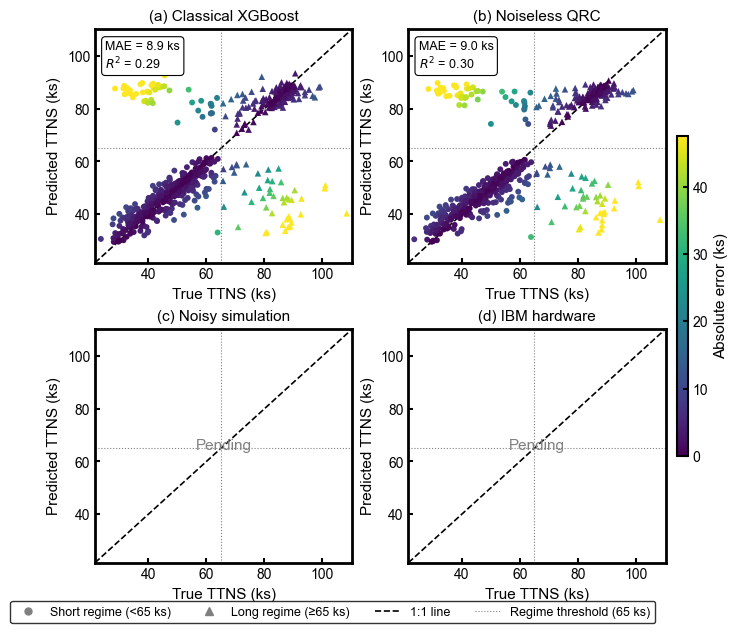

In [34]:
# ── Four-panel publication figure: Classical / Noiseless QRC / Noisy sim / Hardware
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

from matplotlib.lines import Line2D
from sklearn.metrics import mean_absolute_error, r2_score
 
# ── Figure specifications ──────────────────────────────────────────────────────
# Double-column journal figure: 6.89" wide (175 mm)
# Arial 11pt axis labels, Arial 10pt ticks
# No grey background, no gridlines, no bold/italic
# Double-coded: color (viridis) + marker shape
# Black box border, lineweight 2
 
mpl.rcParams.update({
    'font.family':       'Arial',
    'font.size':         11,
    'axes.linewidth':    2,
    'axes.edgecolor':    'black',
    'axes.facecolor':    'white',
    'figure.facecolor':  'white',
    'axes.grid':         False,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'font.style':        'normal',
    'font.weight':       'normal',
    'axes.titleweight':  'normal',
    'axes.labelweight':  'normal',
})
 
# ── Data preparation ──────────────────────────────────────────────────────────
# True values — shared across all panels
y_true = np.array(y_test_np)
 
# Classical XGBoost — from constrained pipeline
classical_preds  = np.array(final_predictions)
classical_errors = np.abs(classical_preds - y_true)
 
# Classifier routing labels — needed for double-coding marker shape
# 0 = routed to short regime, 1 = routed to long regime
clf_labels       = np.array(clf_test_labels)          # classifier routing decision
true_labels      = (y_true >= SHORT_THRESHOLD).astype(int)  # ground-truth regime
misrouted_mask   = clf_labels != true_labels
 
# Noiseless QRC — ensemble predictions from run_qrc_pipeline
qrc_preds  = np.array(ensemble_pred)
qrc_errors = np.abs(qrc_preds - y_true)
 
# Noisy simulation and hardware — leave as None until available
# When ready, replace None with: np.array(your_predictions)
noisy_preds    = None
hardware_preds = None
 
# ── Regime index masks (based on true label, not classifier routing) ──────────
# This is consistent with how per-regime MAE is reported in run_qrc_pipeline
short_idx = y_true < SHORT_THRESHOLD   # true short-interval events
long_idx  = ~short_idx                 # true long-interval events
 
# ── Axis limits (shared across all panels) ────────────────────────────────────
all_vals = np.concatenate([y_true, classical_preds, qrc_preds])
ax_min   = max(0, np.min(all_vals) - 2000)
ax_max   = np.max(all_vals) + 2000
diag     = [ax_min, ax_max]
 
# ── Colormap and normalisation (shared across all panels) ────────────────────
# Clip top 5% of errors so colorbar is not dominated by outliers
all_errors = np.concatenate([classical_errors, qrc_errors])
vmin, vmax = 0, np.percentile(all_errors, 95)
cmap = plt.cm.viridis
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
 
 
# ── Plotting function ─────────────────────────────────────────────────────────
def scatter_regime(ax, y_true, y_pred, errors, title,
                   short_idx, long_idx, is_placeholder=False):
    """
    Plot one panel of the four-panel figure.
    Double-coded: short-regime events = circles, long-regime events = triangles.
    Regime membership is based on true label, not classifier routing.
    """
    ax.set_xlim(ax_min, ax_max)
    ax.set_ylim(ax_min, ax_max)
 
    # Perfect prediction diagonal
    ax.plot(diag, diag, color='black', linewidth=1.2,
            linestyle='--', zorder=1, label='1:1 line')
 
    # Regime threshold reference lines
    ax.axvline(SHORT_THRESHOLD, color='grey', linestyle=':',
               linewidth=0.8, zorder=1)
    ax.axhline(SHORT_THRESHOLD, color='grey', linestyle=':',
               linewidth=0.8, zorder=1)
 
    if is_placeholder:
        ax.text(
            0.5, 0.5, 'Pending',
            transform=ax.transAxes,
            ha='center', va='center',
            fontsize=11, color='gray'
        )
        ax.set_title(title, fontsize=11, pad=6)
        ax.set_xlabel('True TTNS (ks)', fontsize=11)
        ax.set_ylabel('Predicted TTNS (ks)', fontsize=11)
        _format_axes_ks(ax)
        return None
 
    # Short regime — circles
    ax.scatter(
        y_true[short_idx], y_pred[short_idx],
        c=errors[short_idx], cmap=cmap, norm=norm,
        s=18, marker='o', edgecolors='none', zorder=2
    )
    # Long regime — triangles
    ax.scatter(
        y_true[long_idx], y_pred[long_idx],
        c=errors[long_idx], cmap=cmap, norm=norm,
        s=22, marker='^', edgecolors='none', zorder=2
    )
 
    # MAE and R² annotation box
    mae = mean_absolute_error(y_true, y_pred)
    r2  = r2_score(y_true, y_pred)
    ax.text(
        0.04, 0.95,
        f'MAE = {mae/1000:.1f} ks\n$R^2$ = {r2:.2f}',
        transform=ax.transAxes,
        ha='left', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor='black', linewidth=0.8)
    )
 
    ax.set_title(title, fontsize=11, pad=6)
    ax.set_xlabel('True TTNS (ks)', fontsize=11)
    ax.set_ylabel('Predicted TTNS (ks)', fontsize=11)
    _format_axes_ks(ax)
    return ax
 
 
def _format_axes_ks(ax):
    """Convert axis tick labels from seconds to kiloseconds."""
    ax.xaxis.set_major_formatter(
        mpl.ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}')
    )
    ax.yaxis.set_major_formatter(
        mpl.ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}')
    )
 
 
# ── Build figure ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    2, 2,
    figsize=(6.89, 6.0),
    constrained_layout=True
)
 
scatter_regime(
    axes[0, 0], y_true, classical_preds, classical_errors,
    '(a) Classical XGBoost',
    short_idx, long_idx
)
scatter_regime(
    axes[0, 1], y_true, qrc_preds, qrc_errors,
    '(b) Noiseless QRC',
    short_idx, long_idx
)
scatter_regime(
    axes[1, 0], y_true, None, None,
    '(c) Noisy simulation',
    short_idx, long_idx,
    is_placeholder=True
)
scatter_regime(
    axes[1, 1], y_true, None, None,
    '(d) IBM hardware',
    short_idx, long_idx,
    is_placeholder=True
)
 
# ── Shared colorbar ───────────────────────────────────────────────────────────
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, shrink=0.6, pad=0.02, aspect=30)
cbar.set_label('Absolute error (ks)', fontsize=11)
cbar.ax.yaxis.set_major_formatter(
    mpl.ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}')
)
cbar.ax.tick_params(labelsize=10)
cbar.outline.set_linewidth(1.5)
 
# ── Shared legend ─────────────────────────────────────────────────────────────
legend_elements = [
    Line2D([0], [0], marker='o', color='gray', linestyle='None',
           markersize=5, label='Short regime (<65 ks)'),
    Line2D([0], [0], marker='^', color='gray', linestyle='None',
           markersize=6, label='Long regime (≥65 ks)'),
    Line2D([0], [0], color='black', linestyle='--',
           linewidth=1.2, label='1:1 line'),
    Line2D([0], [0], color='grey', linestyle=':',
           linewidth=0.8, label='Regime threshold (65 ks)'),
]
fig.legend(
    handles=legend_elements,
    loc='lower center',
    ncol=4,
    fontsize=9,
    frameon=True,
    edgecolor='black',
    bbox_to_anchor=(0.42, -0.04)
)
 
# ── Save ──────────────────────────────────────────────────────────────────────
'''output_path = 'insert path'
fig.savefig(
    output_path,
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()
print(f"Saved to {output_path}")'''

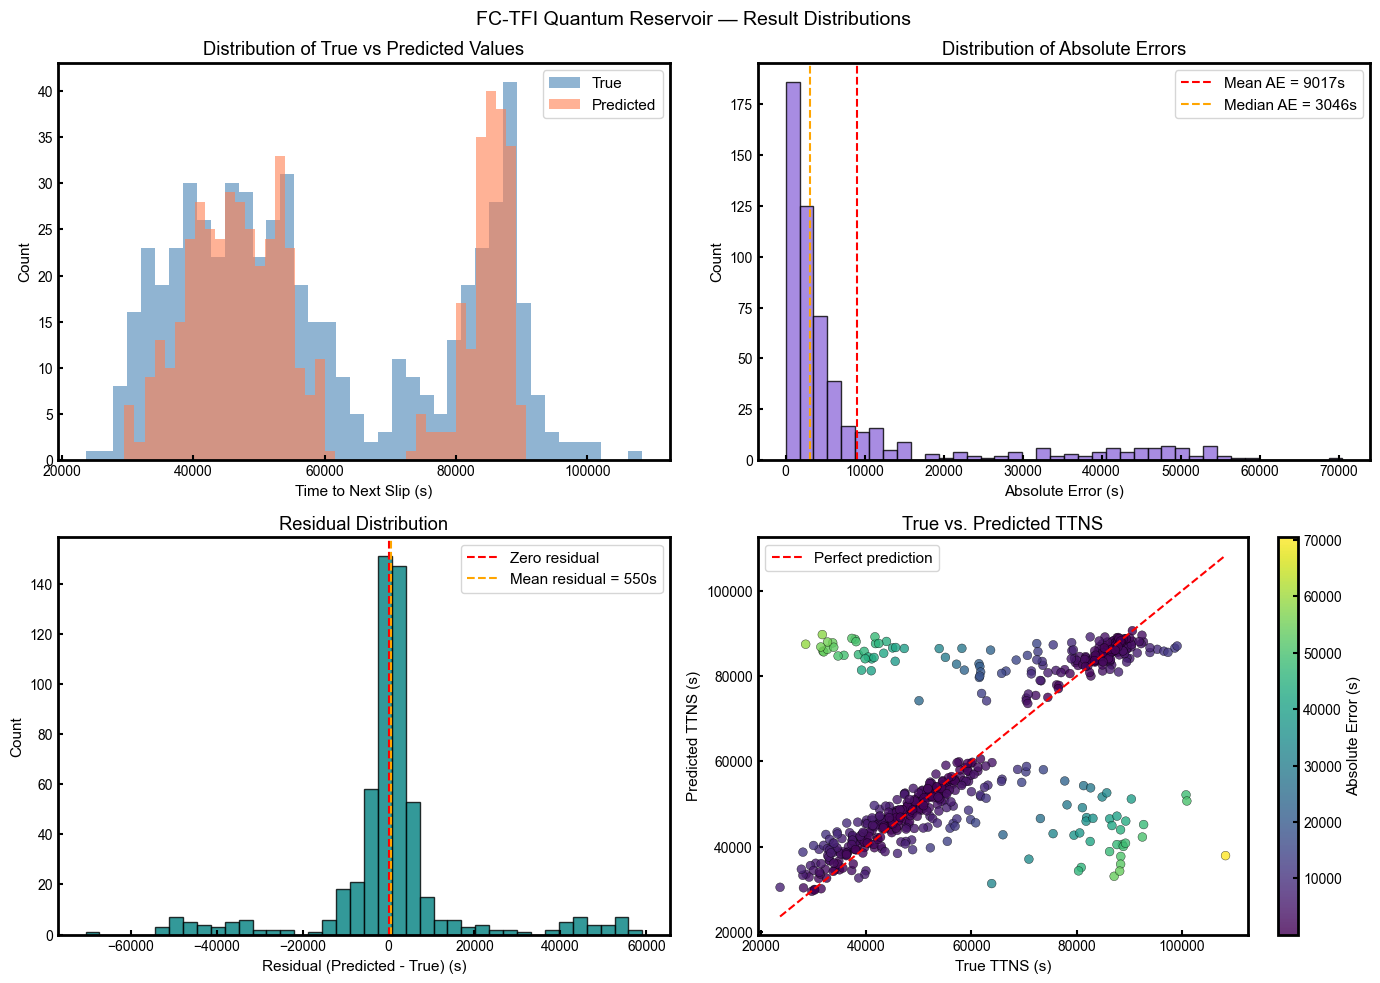

MAE:            9017.11s
Median AE:      3045.53s
RMSE:           16891.74s
R2:             0.2966
Max error:      70485.34s
% within 5000s: 65.1%
% within 9000s: 77.7%


In [37]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score

# ── Data distribution plot for FC-TFI run ────────────────────────────────────
y_test_secs    = y_test
QRC_pred_secs  = ensemble_pred

absolute_errors = np.abs(QRC_pred_secs - y_test_secs)
residuals       = QRC_pred_secs - y_test_secs

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("FC-TFI Quantum Reservoir — Result Distributions", fontsize=14)

# ── Panel 1: Distribution of true vs predicted values ────────────────────────
axes[0, 0].hist(y_test_secs, bins=40, alpha=0.6, color='steelblue', label='True')
axes[0, 0].hist(QRC_pred_secs, bins=40, alpha=0.6, color='coral', label='Predicted')
axes[0, 0].set_xlabel("Time to Next Slip (s)")
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_title("Distribution of True vs Predicted Values")
axes[0, 0].legend()

# ── Panel 2: Distribution of absolute errors ──────────────────────────────────
axes[0, 1].hist(absolute_errors, bins=40, color='mediumpurple', edgecolor='black', alpha=0.8)
axes[0, 1].axvline(absolute_errors.mean(), color='red', linestyle='--',
                    label=f'Mean AE = {absolute_errors.mean():.0f}s')
axes[0, 1].axvline(np.median(absolute_errors), color='orange', linestyle='--',
                    label=f'Median AE = {np.median(absolute_errors):.0f}s')
axes[0, 1].set_xlabel("Absolute Error (s)")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_title("Distribution of Absolute Errors")
axes[0, 1].legend()

# ── Panel 3: Residuals distribution ──────────────────────────────────────────
axes[1, 0].hist(residuals, bins=40, color='teal', edgecolor='black', alpha=0.8)
axes[1, 0].axvline(0, color='red', linestyle='--', label='Zero residual')
axes[1, 0].axvline(residuals.mean(), color='orange', linestyle='--',
                    label=f'Mean residual = {residuals.mean():.0f}s')
axes[1, 0].set_xlabel("Residual (Predicted - True) (s)")
axes[1, 0].set_ylabel("Count")
axes[1, 0].set_title("Residual Distribution")
axes[1, 0].legend()

# ── Panel 4: True vs Predicted scatter ───────────────────────────────────────
sc = axes[1, 1].scatter(y_test_secs, QRC_pred_secs,
                         c=absolute_errors, cmap='viridis',
                         s=40, edgecolors='black', linewidths=0.3, alpha=0.8)
plt.colorbar(sc, ax=axes[1, 1], label="Absolute Error (s)")
axes[1, 1].plot([y_test_secs.min(), y_test_secs.max()],
                [y_test_secs.min(), y_test_secs.max()],
                'r--', linewidth=1.5, label='Perfect prediction')
axes[1, 1].set_xlabel("True TTNS (s)")
axes[1, 1].set_ylabel("Predicted TTNS (s)")
axes[1, 1].set_title("True vs. Predicted TTNS")
axes[1, 1].legend()

plt.tight_layout()
plt.show()


# ── Summary stats ─────────────────────────────────────────────────────────────
print(f"MAE:            {mean_absolute_error(y_test_secs, QRC_pred_secs):.2f}s")
print(f"Median AE:      {np.median(absolute_errors):.2f}s")
print(f"RMSE:           {np.sqrt(np.mean(residuals**2)):.2f}s")
print(f"R2:             {r2_score(y_test_secs, QRC_pred_secs):.4f}")
print(f"Max error:      {absolute_errors.max():.2f}s")
print(f"% within 5000s: {(absolute_errors < 5000).mean()*100:.1f}%")
print(f"% within 9000s: {(absolute_errors < 9000).mean()*100:.1f}%")